# Kelompok 4.1 (NLP)
# Penerapan Long Short Term Memory (LSTM) untuk Deteksi Awal Gangguan Mental
Anggota:


1. E1E122124 MURSAWAL
2. E1E122004 ANNISA NURFADILAH
3. E1E122003 ANNISA AULIYA RAMADHANI



# Import Library

In [56]:
import pandas as pd
import numpy as np
import re
import seaborn as sns
import matplotlib.pyplot as plt
from wordcloud import WordCloud,STOPWORDS
from textblob import Word
from sklearn.metrics import classification_report,confusion_matrix

In [57]:
import nltk
nltk.download('wordnet')
nltk.download('stopwords')
nltk.download("omw-1.4")

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [58]:
from tensorflow.keras.layers import Input, Dense, Activation, Bidirectional, LSTM, Dropout, Embedding
from tensorflow.keras.losses import sparse_categorical_crossentropy
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing import sequence
from tensorflow.keras.callbacks import EarlyStopping

# EDA (Exploratory Data Analysis)

In [59]:
df=pd.read_csv("/content/Mental_Helath_Dataset.csv")
dforig=df.copy()
df.head()

,subreddit,date,post
0,anxiety,2019/03/14,small victory (19M) It's like I just woke up r...
1,anxiety,2019/03/30,"Every time I go out, in the morning I assume e..."
2,anxiety,2019/03/28,How to deal with the burning chest sensation F...
3,anxiety,2019/04/10,Anxious about applying for a job I only half w...
4,anxiety,2019/03/28,Been on lexapro for anxiety for over 2 weeks -...


In [60]:
df.shape

(6000, 3)

In [61]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   subreddit  6000 non-null   object
 1   date       6000 non-null   object
 2   post       6000 non-null   object
dtypes: object(3)
memory usage: 140.8+ KB


In [62]:
df = df.drop(columns=['date'])
df

,subreddit,post
0,anxiety,small victory (19M) It's like I just woke up r...
1,anxiety,"Every time I go out, in the morning I assume e..."
2,anxiety,How to deal with the burning chest sensation F...
3,anxiety,Anxious about applying for a job I only half w...
4,anxiety,Been on lexapro for anxiety for over 2 weeks -...
...,...,...
5995,schizophrenia,Do I have schizophrenia? Hi! My name is Rares ...
5996,schizophrenia,ill never win the war but I won some battles B...
5997,schizophrenia,I think I might be developing schizophrenia or...
5998,schizophrenia,Taking meds Ive been recently diagnosed and I'...


In [63]:
df.rename(columns={"subreddit": "label"}, inplace=True)

In [64]:
df.label.value_counts()

,count
label,
anxiety,1500
bipolarreddit,1500
depression,1500
schizophrenia,1500


In [65]:
df = df[~df['label'].isin(['bipolarreddit', 'schizophrenia'])]
df

,label,post
0,anxiety,small victory (19M) It's like I just woke up r...
1,anxiety,"Every time I go out, in the morning I assume e..."
2,anxiety,How to deal with the burning chest sensation F...
3,anxiety,Anxious about applying for a job I only half w...
4,anxiety,Been on lexapro for anxiety for over 2 weeks -...
...,...,...
4495,depression,my fucked up life I'm a 20 year old male strug...
4496,depression,"Is this normal on Lexapro? Hi all,\n\n&amp;#x2..."
4497,depression,Just wrote this and I am still super drunk I’v...
4498,depression,I've been depressed for 6 years now I've been ...


In [66]:
df.label.value_counts()

,count
label,
anxiety,1500
depression,1500


In [67]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3000 entries, 0 to 4499
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   label   3000 non-null   object
 1   post    3000 non-null   object
dtypes: object(2)
memory usage: 70.3+ KB


In [68]:
df.head()

,label,post
0,anxiety,small victory (19M) It's like I just woke up r...
1,anxiety,"Every time I go out, in the morning I assume e..."
2,anxiety,How to deal with the burning chest sensation F...
3,anxiety,Anxious about applying for a job I only half w...
4,anxiety,Been on lexapro for anxiety for over 2 weeks -...


# Visualisasi Data (Sebelum Preprocessing)

<ipython-input-69-3e48e04623e2>:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x = df['label'], palette = 'Set1', alpha = 0.7)


Text(0.5, 1.0, 'Distribution of Target')

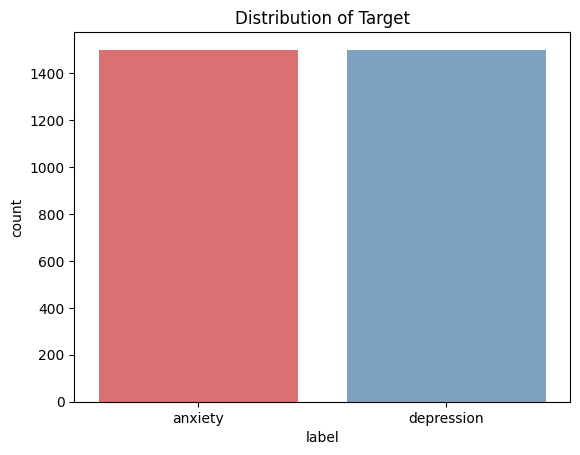

In [69]:
sns.countplot(x = df['label'], palette = 'Set1', alpha = 0.7)
plt.title('Distribution of Target')

# Preprocessing Data

In [70]:
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords
sw=stopwords.words('english')
sw.extend(['going','im','one','u','dont'])
lemma=WordNetLemmatizer()

In [71]:
nltk.download('punkt_tab')
nltk.download('averaged_perceptron_tagger')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


True

In [72]:
!pip install nltk
import nltk
nltk.download('averaged_perceptron_tagger_eng')
import re
import string
import pandas as pd

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag, word_tokenize
from nltk.corpus import wordnet

# Inisialisasi objek
lemmatizer = WordNetLemmatizer()

# Custom stopwords list (tanpa menghapus kata negatif)
stop_words = set(stopwords.words('english')) - {'not', 'never', "don't", "isn't", "wasn't", "hasn't", "hadn't"}

# Slang dictionary
slang_dict = {
    "u": "you",
    "im": "i am",
    "dont": "do not",
    "idk": "i do not know",
    "ive": "i have",
    "i've": "i have",
    ":)": "happy",
    ":(" : "sad"
}

# Fungsi mengganti slang words
def replace_slang(post):
    words = post.split()
    return ' '.join([slang_dict[word] if word in slang_dict else word for word in words])

# Fungsi konversi POS Tag ke WordNet
def get_wordnet_pos(word):
    tag = pos_tag([word])[0][1][0].upper()
    tag_dict = {"J": wordnet.ADJ, "N": wordnet.NOUN, "V": wordnet.VERB, "R": wordnet.ADV}
    return tag_dict.get(tag, wordnet.NOUN)

# Fungsi preprocessing
def preprocess_text(post):
    post = post.lower()
    post = re.sub(r'http\S+|www\S+', '', post)  # Hapus URL
    post = re.sub(r'@\w+|#\w+', '', post)  # Hapus mention & hashtag
    post = re.sub(r'[^a-zA-Z\s]', '', post)  # Hapus karakter selain huruf
    post = re.sub(r'\s+', ' ', post).strip()  # Hapus spasi berlebih

    # Ganti slang words
    post = replace_slang(post)

    # Tokenizing
    tokens = word_tokenize(post)

    # Filtering stopwords & lemmatization
    tokens = [lemmatizer.lemmatize(word, get_wordnet_pos(word)) for word in tokens if word not in stop_words and word not in string.punctuation]

    return ' '.join(tokens)

# Contoh penggunaan
df['clean_post'] = df['post'].apply(preprocess_text)
df = df[['clean_post', 'label']]

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
<ipython-input-72-bce1ab4c799e>:63: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['clean_post'] = df['post'].apply(preprocess_text)


In [73]:
# Mengubah tipe data 'label'. Dari kategorikal ke numerik
label_mapping = {label: i for i, label in enumerate(df['label'].unique())}
df['label'] = df['label'].map(label_mapping)

df['label'].value_counts()
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3000 entries, 0 to 4499
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   clean_post  3000 non-null   object
 1   label       3000 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 70.3+ KB


<ipython-input-73-b1a90d675641>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['label'] = df['label'].map(label_mapping)


In [74]:
df['label'].value_counts()

,count
label,
0,1500
1,1500


In [75]:
df.head()

,clean_post,label
0,small victory like woke recently realize miss ...,0
1,every time go morning assume everyone hate bad...,0
2,deal burning chest sensation half day chest bu...,0
3,anxious apply job half want also anxious not g...,0
4,lexapro anxiety week thought anxiety drastical...,0


# Visualisasi Panjang Teks di Tiap Label

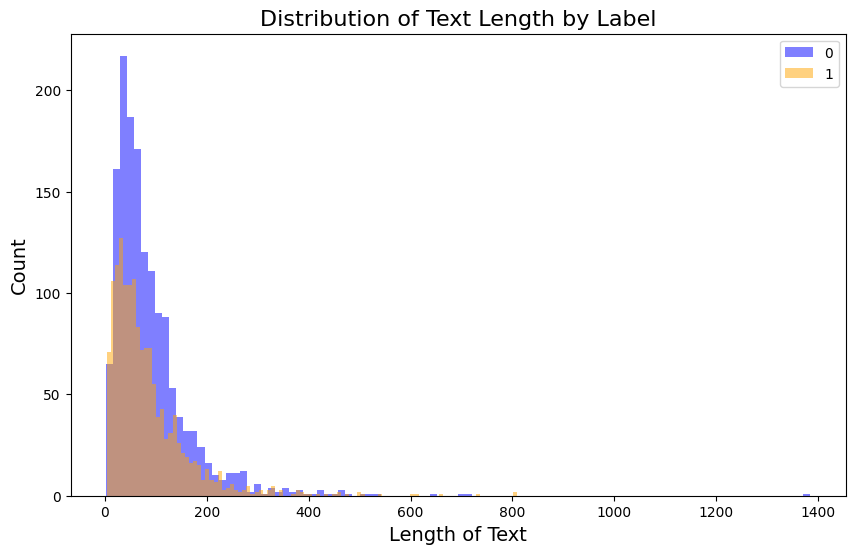

In [76]:
# Hitung panjang teks
df["frequency"] = df["clean_post"].apply(lambda x: len(str(x).split(" ")))

# Set ukuran plot
plt.figure(figsize=(10, 6))

# Buat warna dan label berbeda untuk setiap label
labels = [0, 1]
colors = ['blue', 'orange']
for sub, color in zip(labels, colors):
    plt.hist(
        df[df.label == sub]['frequency'],
        bins=100,
        alpha=0.5,
        color=color,
        label=sub
    )

# Tambahkan keterangan
plt.xlabel("Length of Text", size=14)
plt.ylabel("Count", size=14)
plt.title("Distribution of Text Length by Label", size=16)
plt.legend(loc='upper right')
plt.grid(False)
plt.show()

# Visualisasi Keseluruhan Data

Text(0.5, 1.0, 'Overall post')

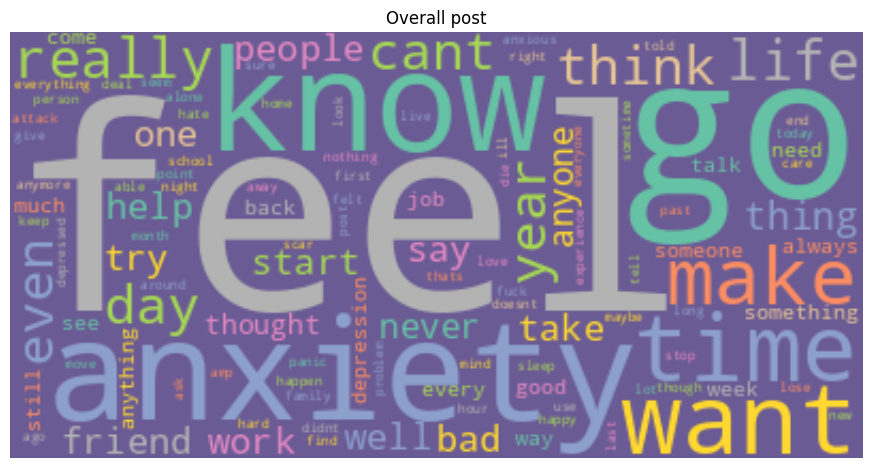

In [77]:
text = " ".join(i for i in df.clean_post)
wordcloud = WordCloud(background_color="#6B5B95",colormap="Set2",collocations=False).generate(text)
plt.figure(figsize=[11,11])
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Overall post")

# Visualisasi Data Anxiety

Text(0.5, 1.0, 'The post About anxiety')

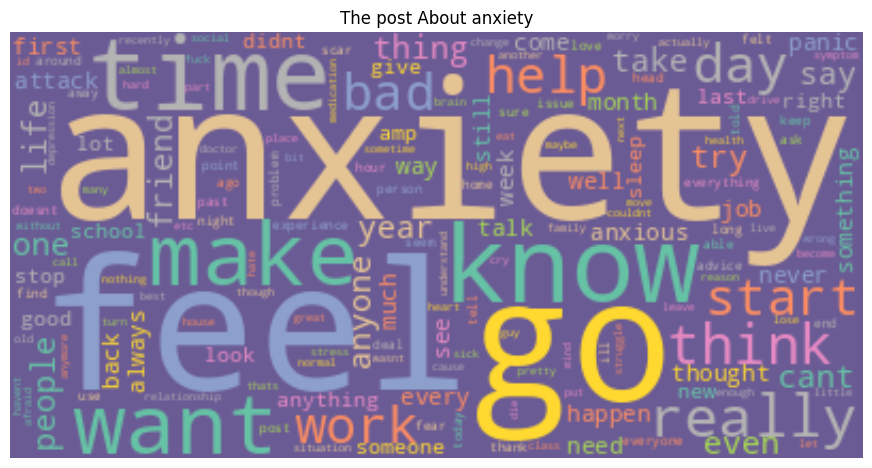

In [78]:
text = " ".join(i for i in df[df.label==0].clean_post)
wordcloud = WordCloud(background_color="#6B5B95",colormap="Set2",collocations=False).generate(text)
plt.figure(figsize=[11,11])
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("The post About anxiety")

# Visualisasi Data Depression

Text(0.5, 1.0, 'The post About depression')

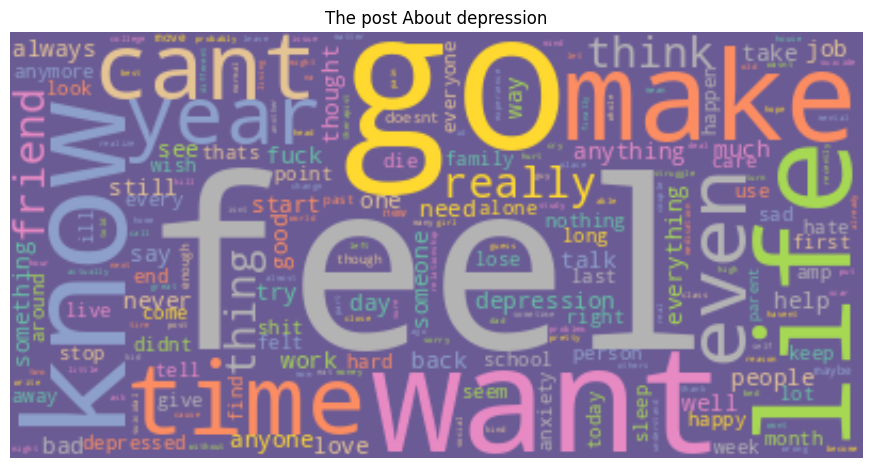

In [79]:
text = " ".join(i for i in df[df.label==1].clean_post)
wordcloud = WordCloud(background_color="#6B5B95",colormap="Set2",collocations=False).generate(text)
plt.figure(figsize=[11,11])
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("The post About depression")

# Pembagian Data Menggunakan Stratified K-Fold Cross-Validation

In [80]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import StratifiedKFold

# Tokenizer setup
tokenizer = Tokenizer(num_words=10000, oov_token='<OOV>')
tokenizer.fit_on_texts(df['clean_post'])

X = df['clean_post']
y = df['label']

# Convert to sequences
X_seq = tokenizer.texts_to_sequences(X)
X_pad = pad_sequences(X_seq, maxlen=100)  # Panjang maksimal bisa disesuaikan

X_pad = np.array(X_pad)
y = np.array(y)

# Stratified K-Fold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for fold, (train_index, test_index) in enumerate(skf.split(X_pad, y), 1):
    print(f"\nFold {fold}")

    X_train, X_test = X_pad[train_index], X_pad[test_index]
    y_train, y_test = y[train_index], y[test_index]


Fold 1

Fold 2

Fold 3

Fold 4

Fold 5


In [81]:
print("Total data:", len(df))
print("Jumlah data training:", len(X_train))
print("Jumlah data testing:", len(X_test))

Total data: 3000
Jumlah data training: 2400
Jumlah data testing: 600


# Menghitung Bobot Kelas

In [82]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights_dict = {i : weight for i, weight in enumerate(class_weights)}

# Modeling

In [83]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, MaxPooling1D, Bidirectional, LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2

MAX_SEQUENCE_LENGTH = 100

# Definisikan model
model = Sequential([
    Embedding(input_dim=10000, output_dim=128),  # Hapus input_length di sini
    Conv1D(filters=64, kernel_size=5, activation='relu', padding='same'),
    MaxPooling1D(pool_size=2),
    BatchNormalization(),
    Bidirectional(LSTM(64, return_sequences=True, dropout=0.3, recurrent_dropout=0.3)),
    Bidirectional(LSTM(32, dropout=0.3, recurrent_dropout=0.3)),
    Dense(128, activation='relu', kernel_regularizer=l2(0.01)),
    Dropout(0.5),
    Dense(64, activation='relu', kernel_regularizer=l2(0.01)),
    Dropout(0.5),
    Dense(2, activation='softmax')
])

# Kompilasi model
model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=Adam(learning_rate=0.0003),
    metrics=['accuracy']
)

# Bangun layer-layer dengan input dummy
dummy_input = tf.zeros((1, MAX_SEQUENCE_LENGTH))
model(dummy_input)

# Tampilkan ringkasan model
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (1, 100, 128)          │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (1, 100, 64)           │        41,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (1, 50, 64)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (1, 50, 64)            │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_6 (Bidirectional) │ (1, 50, 128)           │        66,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_7 (Bidirectional) │ (1, 64)                │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (1, 128)               │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (1, 128)               │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (1, 64)                │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (1, 64)                │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (1, 2)                 │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,445,250 (5.51 MB)

 Trainable params: 1,445,122 (5.51 MB)

 Non-trainable params: 128 (512.00 B)

In [84]:
class myCallback(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs={}):
        if (logs.get('accuracy') is not None and logs.get('accuracy') > 0.91) and  \
           (logs.get('val_accuracy') is not None and logs.get('val_accuracy') > 0.91):
            print('\nAkurasi pada data latih telah mencapai > 90% ')
            self.model.stop_training = True

In [85]:
from tensorflow.keras.callbacks import EarlyStopping

# Definisi EarlyStopping
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# Latih model dengan callback baru
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=100,
    class_weight=class_weights_dict,
    callbacks=[myCallback(),early_stopping]  # Perbaikan di bagian ini ✅
)

Epoch 1/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 48s 246ms/step - accuracy: 0.5201 - loss: 2.3203 - val_accuracy: 0.5017 - val_loss: 2.0154
Epoch 2/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 22s 271ms/step - accuracy: 0.5573 - loss: 1.9190 - val_accuracy: 0.7550 - val_loss: 1.6822
Epoch 3/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 19s 245ms/step - accuracy: 0.7880 - loss: 1.4713 - val_accuracy: 0.8217 - val_loss: 1.2323
Epoch 4/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 19s 220ms/step - accuracy: 0.9276 - loss: 0.9823 - val_accuracy: 0.8400 - val_loss: 0.9758
Epoch 5/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 23s 247ms/step - accuracy: 0.9403 - loss: 0.7657 - val_accuracy: 0.8667 - val_loss: 0.7909
Epoch 6/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 19s 227ms/step - accuracy: 0.9669 - loss: 0.5597 - val_accuracy: 0.8617 - val_loss: 0.7693
Epoch 7/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 20s 219ms/step - accuracy: 0.9789 - loss: 0.4203 - val_accuracy: 0.8700 - val_loss: 0.6805
Epoch 8/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 18s 244ms/step - accuracy: 0.9811 - loss: 0.3415 - 

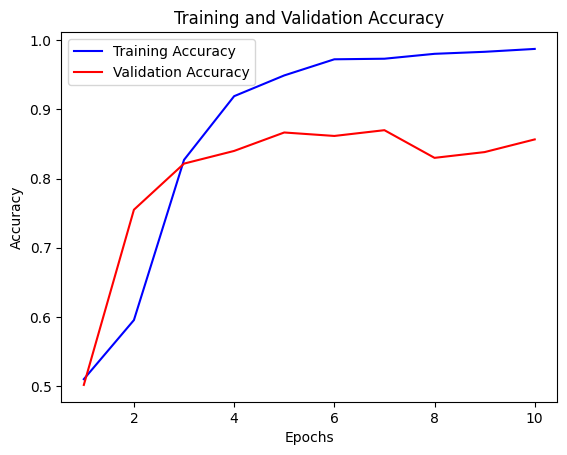

In [86]:
import matplotlib.pyplot as plt

history_dict = history.history

# Ambil data akurasi dan val_akurasi
train_acc = history_dict['accuracy']
val_acc = history_dict['val_accuracy']
epochs = range(1, len(train_acc) + 1)

# Bikin plot
plt.plot(epochs, train_acc, 'b-', label='Training Accuracy')
plt.plot(epochs, val_acc, 'r-', label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

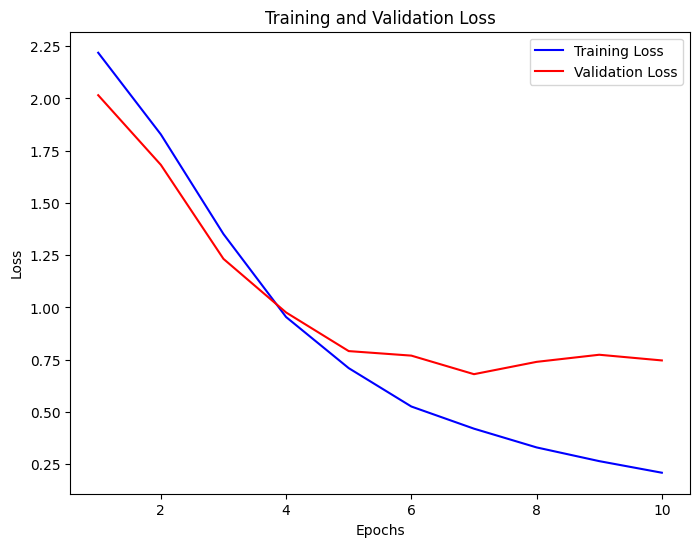

In [87]:
import matplotlib.pyplot as plt

# Ambil data loss dari training
train_loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(train_loss) + 1)

# Plot loss
plt.figure(figsize=(8, 6))
plt.plot(epochs, train_loss, 'b-', label='Training Loss')
plt.plot(epochs, val_loss, 'r-', label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Test Data

In [88]:
print(y_test.shape)
print(y_test[:5])

(600,)
[0 0 0 0 0]


19/19 ━━━━━━━━━━━━━━━━━━━━ 4s 134ms/step
Confusion Matrix:
 [[258  42]
 [ 36 264]]


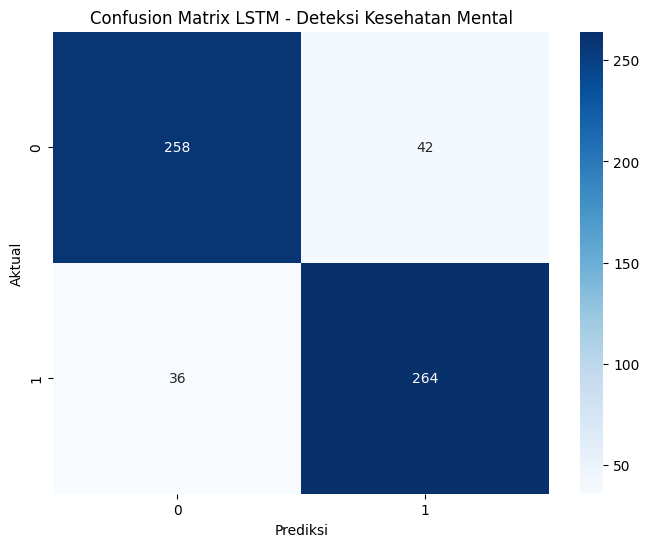

In [89]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_test = le.fit_transform(y_test)

y_pred = np.argmax(model.predict(X_test), axis=1)
y_true = y_test  # langsung pakai tanpa np.argmax()

cm = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:\n", cm)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Prediksi")
plt.ylabel("Aktual")
plt.title("Confusion Matrix LSTM - Deteksi Kesehatan Mental")
plt.show()

In [90]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['anxiety', 'depression']))


Classification Report:
              precision    recall  f1-score   support

     anxiety       0.88      0.86      0.87       300
  depression       0.86      0.88      0.87       300

    accuracy                           0.87       600
   macro avg       0.87      0.87      0.87       600
weighted avg       0.87      0.87      0.87       600



In [91]:
model.save("model_mental_health_v1.h5")